# Full-GAVD GaitParity replication — CPU

This launcher reproduces the strongest supported **cpu** protocol on the locked
96-sequence GAVD pose cache. It executes 09c (contract), 09d (training), and 09e
(audit) for seeds 7, 19, and 31 under both exposure- and compute-matched allocation.

Configuration: 64 frames, stride 64, 8-frame segments, width 32, two encoder layers, one predictor layer, batch size 8, and six epochs.

This is local, transductive representation/geometry evidence only. It is not clinical
or held-out-video generalization evidence.

## Before running

1. Use the `python3` kernel created by `uv sync`.
2. Ensure a complete real pose cache exists: 12 normal, 9 Parkinson's, 12 stroke,
   47 myopathic, and 16 cerebral-palsy sequences.
3. Set `RUN_PIPELINE = True` only when ready. Leaving it `False` performs no training.

The launcher writes the executed child notebooks beside each run's artifacts so the
exact contract, training, and audit outputs are retained.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "gait_parity_jepa.py").is_file():
    raise FileNotFoundError("Open this launcher from experiments/sjepa/gavd6.")
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from gait_parity_jepa import EXPECTED_COUNTS, load_gavd_records

RUN_PIPELINE = True  # Explicit opt-in. Change to True to start the 18 trainings.
RUN_ID = "gavd96-cpu-strong-v1"
PROFILE = "cpu"
DEVICE = "cpu"
SEEDS = "7,19,31"
MATCHING_REGIMES = ("exposure", "compute")

# Use a local gavd6 cache by default. Set this environment variable to a mounted,
# immutable 96-sequence cache if it lives elsewhere.
POSE_DIR = Path(os.getenv(
    "GAIT_PARITY_POSE_DIR",
    PROJECT_DIR / "work" / "artifacts" / "real" / "poses",
)).expanduser().resolve()

print({
    "run_pipeline": RUN_PIPELINE,
    "run_id": RUN_ID,
    "profile": PROFILE,
    "device": DEVICE,
    "seeds": SEEDS,
    "matching_regimes": MATCHING_REGIMES,
    "pose_dir": str(POSE_DIR),
})

{'run_pipeline': True, 'run_id': 'gavd96-cpu-strong-v1', 'profile': 'cpu', 'device': 'cpu', 'seeds': '7,19,31', 'matching_regimes': ('exposure', 'compute'), 'pose_dir': '/Users/theodoremui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/poses'}


In [2]:
if RUN_PIPELINE:
    if DEVICE == "cuda":
        import torch
        if not torch.cuda.is_available():
            raise RuntimeError("This replication launcher requires a CUDA-enabled PyTorch host.")
    if not POSE_DIR.is_dir():
        raise FileNotFoundError(f"Full pose cache is missing: {POSE_DIR}")
    records = load_gavd_records(POSE_DIR)
    counts = {condition: sum(record["condition"] == condition for record in records)
              for condition in EXPECTED_COUNTS}
    assert counts == EXPECTED_COUNTS, counts
    print(f"Validated {len(records)} locked GAVD sequences: {counts}")
else:
    print("Dry configuration only — no pose files loaded and no training started.")

Validated 96 locked GAVD sequences: {'normal': 12, 'parkinsons': 9, 'stroke': 12, 'myopathic': 47, 'cerebralpalsy': 16}


## Execute the frozen three-notebook pipeline

For each matching regime, the launcher injects only the declared replication environment
into the child notebook kernels. `09c` writes the immutable contract, `09d` trains and
checkpoints the three variants for every seed, and `09e` audits representation health and
reflection geometry. The child notebooks are copied with their executed outputs into the
matching run directory.

In [3]:
if RUN_PIPELINE:
    import nbformat
    from nbclient import NotebookClient

    child_notebooks = (
        "nb_09c_gavd_matched_jepa_contract.ipynb",
        "nb_09d_gavd_matched_jepa_training.ipynb",
        "nb_09e_gavd_matched_jepa_audit.ipynb",
    )
    base_environment = {
        "GAIT_PARITY_MODE": "real",
        "GAIT_PARITY_PROFILE": PROFILE,
        "GAIT_PARITY_DEVICE": DEVICE,
        "GAIT_PARITY_RUN_ID": RUN_ID,
        "GAIT_PARITY_SEEDS": SEEDS,
        "GAIT_PARITY_POSE_DIR": str(POSE_DIR),
    }

    original_environment = {
        key: os.environ.get(key)
        for key in (*base_environment, "GAIT_PARITY_MATCHING")
    }
    try:
        for matching in MATCHING_REGIMES:
            os.environ.update(base_environment)
            os.environ["GAIT_PARITY_MATCHING"] = matching
            output_dir = (PROJECT_DIR / "work" / "artifacts" / "gait_parity" /
                          "real" / RUN_ID / matching)
            executed_dir = output_dir / "executed_notebooks"
            executed_dir.mkdir(parents=True, exist_ok=True)
            print(f"\n=== {matching}: 09c → 09d → 09e ===")
            for name in child_notebooks:
                notebook = nbformat.read(PROJECT_DIR / name, as_version=4)
                client = NotebookClient(
                    notebook,
                    timeout=None,
                    kernel_name="python3",
                    resources={"metadata": {"path": str(PROJECT_DIR)}},
                )
                client.execute()
                nbformat.write(notebook, executed_dir / name)
                print(f"completed {name}")
    finally:
        for key, value in original_environment.items():
            if value is None:
                os.environ.pop(key, None)
            else:
                os.environ[key] = value
else:
    print("Set RUN_PIPELINE = True in the configuration cell to execute this protocol.")


=== exposure: 09c → 09d → 09e ===


[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.


completed nb_09c_gavd_matched_jepa_contract.ipynb


[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.


completed nb_09d_gavd_matched_jepa_training.ipynb


...

completed nb_09c_gavd_matched_jepa_contract.ipynb


[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.


completed nb_09d_gavd_matched_jepa_training.ipynb


[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.


completed nb_09e_gavd_matched_jepa_audit.ipynb


## Expected output and interpretation

Successful execution produces two training manifests containing eighteen model runs (three
variants, three seeds, and two matching regimes), checkpoints and histories for all seeds, and a checkpoint-health /
geometry audit. A passing audit demonstrates local feasibility and the declared reflection
geometry. It does not establish clinical validity, unseen-video generalization, or a
performance advantage without a predeclared held-out-video evaluation.

## Read the completed run

The cell below reads only what the pipeline already wrote — `checkpoint_health.csv`,
`checkpoint_geometry.csv`, `training_manifest.json`, and the per-run loss histories, for
both matching regimes — and plots the six quantities the contract actually turns on. It
trains nothing and touches no checkpoint, so it is safe to re-run.

Panels A–C are the audited claims: whether the mirror operator commutes with the encoder,
how much representation lives in the mirror-antisymmetric (odd) channel, and how much of
that odd energy is a genuine per-window signal rather than a fixed offset. Panels D–F are
the optimization context: the prediction loss under each allocation rule, the anti-collapse
pressure on the odd channel during training, and the width of each parity channel at the
end.

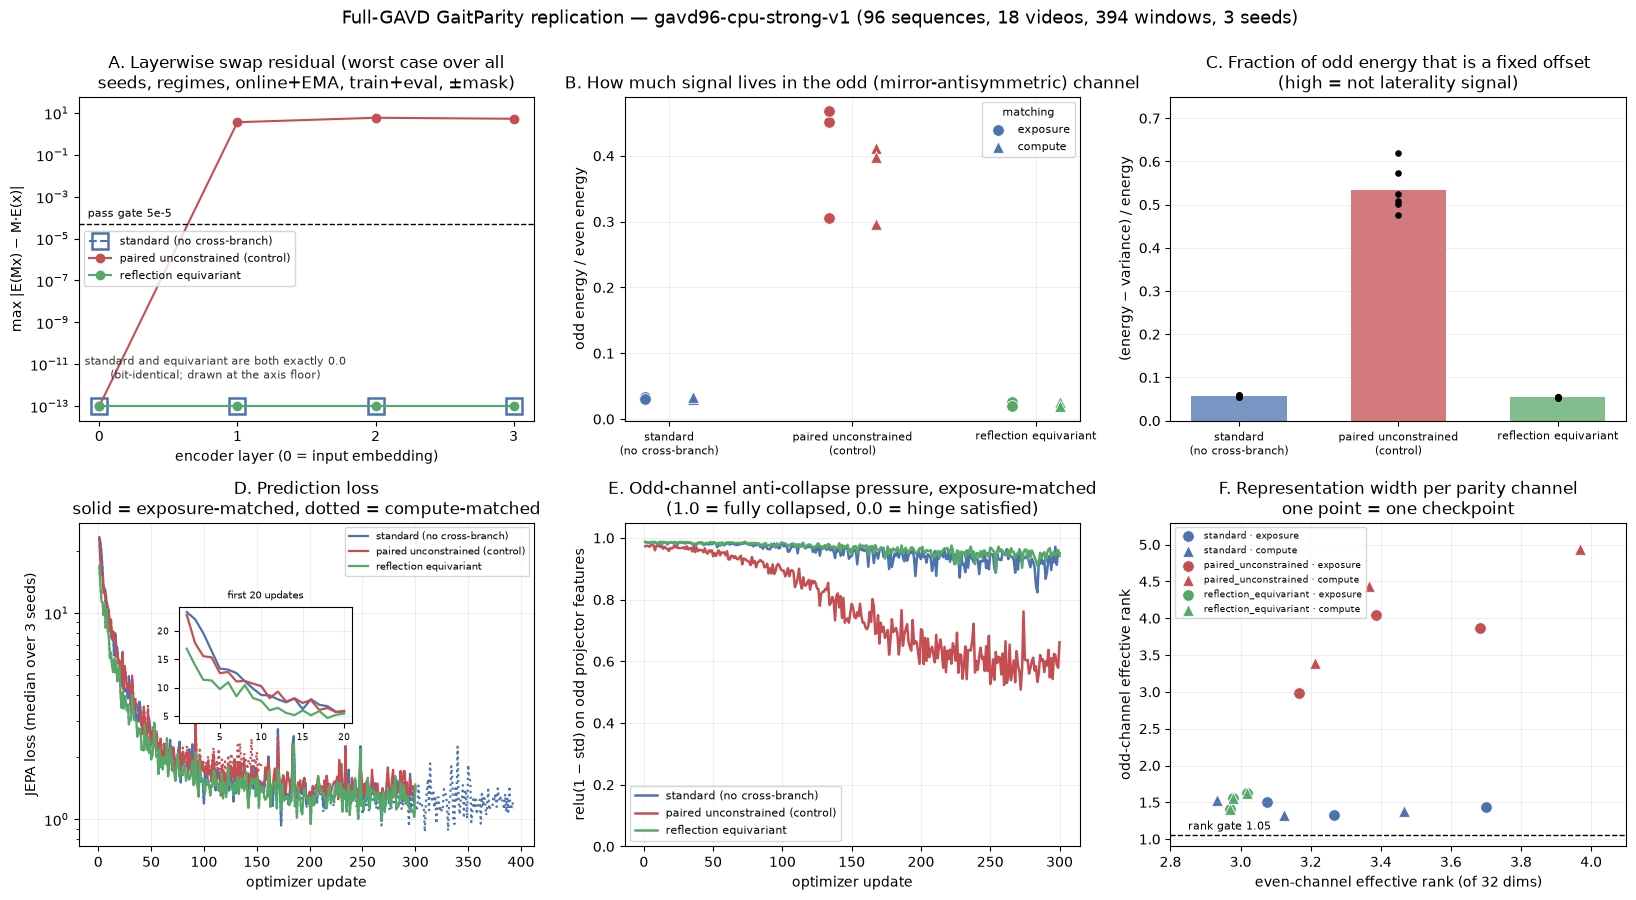

                                 optimizer_updates  orbit_exposures  first_jepa_loss  last_jepa_loss  worst_swap_residual  odd_to_even_energy_ratio  odd_effective_rank  even_effective_rank  odd_common_mode
regime   variant                                                                                                                                                                                             
compute  paired_unconstrained                  155             1240            23.31            1.80             5.286334                     0.369               4.257                3.515            0.520
         reflection_equivariant                300             2400            17.03            1.40             0.000000                     0.022               1.532                2.989            0.055
         standard                              393             3144            24.08            1.26             0.000000                     0.032               1.417         

In [5]:
import json
import matplotlib.pyplot as plt
import pandas as pd

RUN_DIR = PROJECT_DIR / "work" / "artifacts" / "gait_parity" / "real" / RUN_ID
VARIANT_ORDER = ["standard", "paired_unconstrained", "reflection_equivariant"]
VARIANT_COLOR = {"standard": "#4C72B0", "paired_unconstrained": "#C44E52", "reflection_equivariant": "#55A868"}
VARIANT_LABEL = {"standard": "standard\n(no cross-branch)", "paired_unconstrained": "paired unconstrained\n(control)",
                 "reflection_equivariant": "reflection equivariant"}
REGIME_MARKER = {"exposure": "o", "compute": "^"}

health, geometry, history, runs = [], [], [], []
for regime in MATCHING_REGIMES:
    directory = RUN_DIR / regime
    health.append(pd.read_csv(directory / "checkpoint_health.csv").assign(regime=regime))
    geometry.append(pd.read_csv(directory / "checkpoint_geometry.csv").assign(regime=regime))
    manifest = json.loads((directory / "training_manifest.json").read_text())
    runs.append(pd.DataFrame(manifest["runs"]).assign(regime=regime))
    for run in manifest["runs"]:
        history.append(pd.read_csv(run["history"]).assign(
            regime=regime, variant=run["variant"], seed=run["seed"]))
health = pd.concat(health, ignore_index=True)
geometry = pd.concat(geometry, ignore_index=True)
history = pd.concat(history, ignore_index=True)
runs = pd.concat(runs, ignore_index=True)
CONTRACT = json.loads((RUN_DIR / MATCHING_REGIMES[0] / "training_contract.json").read_text())
gates = CONTRACT["health_gates"]
cohort = CONTRACT["cohort_manifest"]

# The odd channel's energy splits into per-window variance and a shared constant offset.
# A large offset share means the "odd" readout is mostly a fixed bias, not laterality signal.
health["odd_common_mode"] = (health.odd_energy - health.odd_feature_variance) / health.odd_energy

figure, axes = plt.subplots(2, 3, figsize=(16.5, 9))
figure.suptitle(
    f"Full-GAVD GaitParity replication — {RUN_ID} "
    f"({cohort['record_count']} sequences, {cohort['source_video_count']} videos, "
    f"{cohort['window_count']} windows, {health.seed.nunique()} seeds)",
    fontsize=13, y=0.995)

# A. Layerwise commutation residual: the predeclared geometry contract.
axis = axes[0, 0]
FLOOR = 1e-13
styles = {"standard": dict(ls="--", marker="s", ms=11, mfc="none", mew=1.8),
          "paired_unconstrained": dict(ls="-", marker="o", ms=6),
          "reflection_equivariant": dict(ls="-", marker="o", ms=6)}
for variant in VARIANT_ORDER:
    frame = geometry[geometry.variant == variant].groupby("layer").max_abs.max()
    axis.plot(frame.index, frame.clip(lower=FLOOR), color=VARIANT_COLOR[variant],
              label=VARIANT_LABEL[variant].replace("\n", " "), **styles[variant])
axis.axhline(gates["equivariance_float32_atol"], color="black", ls="--", lw=1)
axis.text(0.02, gates["equivariance_float32_atol"] * 2.2, "pass gate 5e-5", fontsize=8,
          transform=axis.get_yaxis_transform())
axis.set_yscale("log")
axis.set_ylim(FLOOR / 5, 60)
axis.set_xticks(sorted(geometry.layer.unique()))
axis.set(xlabel="encoder layer (0 = input embedding)", ylabel="max |E(Mx) − M·E(x)|",
         title="A. Layerwise swap residual (worst case over all\nseeds, regimes, online+EMA, train+eval, ±mask)")
axis.text(0.30, 0.13, "standard and equivariant are both exactly 0.0\n(bit-identical; drawn at the axis floor)",
          transform=axis.transAxes, fontsize=8, color="#333", ha="center")
axis.legend(fontsize=8, loc="center left")

# B. Odd/even energy ratio per checkpoint.
axis = axes[0, 1]
for index, variant in enumerate(VARIANT_ORDER):
    for regime in MATCHING_REGIMES:
        frame = health[(health.variant == variant) & (health.regime == regime)]
        offset = -0.13 if regime == "exposure" else 0.13
        axis.scatter([index + offset] * len(frame), frame.odd_to_even_energy_ratio,
                     color=VARIANT_COLOR[variant], marker=REGIME_MARKER[regime], s=70,
                     edgecolor="white", linewidth=0.6,
                     label=regime if index == 0 else None)
axis.set_xticks(range(len(VARIANT_ORDER)))
axis.set_xticklabels([VARIANT_LABEL[v] for v in VARIANT_ORDER], fontsize=8)
axis.set(ylabel="odd energy / even energy",
         title="B. How much signal lives in the odd (mirror-antisymmetric) channel")
axis.legend(fontsize=8, title="matching", title_fontsize=8)
axis.grid(alpha=0.2)

# C. Share of odd energy that is a constant offset rather than per-window variation.
axis = axes[0, 2]
for index, variant in enumerate(VARIANT_ORDER):
    frame = health[health.variant == variant]
    axis.bar(index, frame.odd_common_mode.mean(), color=VARIANT_COLOR[variant], alpha=0.75, width=0.6)
    axis.scatter([index] * len(frame), frame.odd_common_mode, color="black", s=14, zorder=3)
axis.set_xticks(range(len(VARIANT_ORDER)))
axis.set_xticklabels([VARIANT_LABEL[v] for v in VARIANT_ORDER], fontsize=8)
axis.set_ylim(0, 0.75)
axis.set(ylabel="(energy − variance) / energy",
         title="C. Fraction of odd energy that is a fixed offset\n(high = not laterality signal)")
axis.grid(alpha=0.2, axis="y")

# D. JEPA loss trajectories, median across seeds.
axis = axes[1, 0]
for variant in VARIANT_ORDER:
    for regime in MATCHING_REGIMES:
        frame = history[(history.variant == variant) & (history.regime == regime)]
        if frame.empty:
            continue
        curve = frame.groupby("step").jepa_loss.median()
        axis.plot(curve.index, curve.values, color=VARIANT_COLOR[variant],
                  ls="-" if regime == "exposure" else ":", lw=1.6,
                  label=VARIANT_LABEL[variant].replace("\n", " ") if regime == "exposure" else None)
axis.set_yscale("log")
axis.set(xlabel="optimizer update", ylabel="JEPA loss (median over 3 seeds)",
         title="D. Prediction loss\nsolid = exposure-matched, dotted = compute-matched")
axis.legend(fontsize=7, ncol=1, loc="upper right")
axis.grid(alpha=0.2)

# The architectural prior shows up before any gradient step, so zoom the first updates.
inset = axis.inset_axes([0.22, 0.38, 0.38, 0.36])
for variant in VARIANT_ORDER:
    frame = history[(history.variant == variant) & (history.regime == "exposure") & (history.step <= 20)]
    curve = frame.groupby("step").jepa_loss.median()
    inset.plot(curve.index, curve.values, color=VARIANT_COLOR[variant], lw=1.6)
inset.set_title("first 20 updates", fontsize=7.5)
inset.tick_params(labelsize=6.5)
inset.grid(alpha=0.2)

# E. Odd-channel VICReg variance hinge: relu(1 - std), so lower means further from collapse.
axis = axes[1, 1]
for variant in VARIANT_ORDER:
    frame = history[(history.variant == variant) & (history.regime == "exposure")]
    curve = frame.groupby("step").odd_variance.median()
    axis.plot(curve.index, curve.values, color=VARIANT_COLOR[variant], lw=1.8,
              label=VARIANT_LABEL[variant].replace("\n", " "))
axis.set_ylim(0, 1.05)
axis.set(xlabel="optimizer update", ylabel="relu(1 − std) on odd projector features",
         title="E. Odd-channel anti-collapse pressure, exposure-matched\n(1.0 = fully collapsed, 0.0 = hinge satisfied)")
axis.legend(fontsize=8)
axis.grid(alpha=0.2)

# F. Even vs odd effective rank of the 32-dim EMA-teacher representation.
axis = axes[1, 2]
for variant in VARIANT_ORDER:
    for regime in MATCHING_REGIMES:
        frame = health[(health.variant == variant) & (health.regime == regime)]
        axis.scatter(frame.even_effective_rank, frame.odd_effective_rank,
                     color=VARIANT_COLOR[variant], marker=REGIME_MARKER[regime], s=70,
                     edgecolor="white", linewidth=0.6,
                     label=f"{variant} · {regime}")
axis.axhline(gates["minimum_effective_rank"], color="black", ls="--", lw=1)
axis.text(2.85, gates["minimum_effective_rank"] + 0.08, "rank gate 1.05", fontsize=8)
axis.set_xlim(2.8, 4.1)
axis.set_ylim(0.9, 5.3)
axis.set(xlabel="even-channel effective rank (of 32 dims)", ylabel="odd-channel effective rank",
         title="F. Representation width per parity channel\none point = one checkpoint")
axis.legend(fontsize=6.5, loc="upper left")
axis.grid(alpha=0.2)

figure.tight_layout()
plt.show()

summary = (health.groupby(["regime", "variant"])
           [["odd_to_even_energy_ratio", "odd_effective_rank", "even_effective_rank", "odd_common_mode"]]
           .mean().round(3))
worst = geometry.groupby(["regime", "variant"]).max_abs.max().rename("worst_swap_residual")
budget = runs.groupby(["regime", "variant"])[["optimizer_updates", "orbit_exposures"]].max()
losses = runs.groupby(["regime", "variant"])[["first_jepa_loss", "last_jepa_loss"]].mean().round(2)
print(budget.join(losses).join(worst).join(summary).to_string())
for regime in MATCHING_REGIMES:
    verdict = json.loads((RUN_DIR / regime / "checkpoint_audit.json").read_text())["verdict"]
    print(f"\n{regime}: " + json.dumps(verdict, indent=2))